## **Section 1:** Imports and connection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
engine = create_engine("postgresql+psycopg2://dhanushgarikapati@localhost:5432/olist_db")

In [3]:
pd.read_sql("SELECT COUNT(*) AS n FROM analytics.v_orders_enriched;", engine)

,n
0,99441


##### To export visuals

In [43]:
output_dir = Path("../visuals")
output_dir.mkdir(exist_ok=True)

## **Section 2:** Load the main analysis tables

In [4]:
orders = pd.read_sql("""
    SELECT *
    FROM analytics.v_orders_enriched
""", engine)

customers = pd.read_sql("""
    SELECT *
    FROM analytics.v_customer_summary
""", engine)

category_perf = pd.read_sql("""
    SELECT *
    FROM analytics.v_category_performance
""", engine)

seller_perf = pd.read_sql("""
    SELECT *
    FROM analytics.v_seller_performance
""", engine)

state_perf = pd.read_sql("""
    SELECT *
    FROM analytics.v_state_performance
""", engine)

In [5]:
print("orders:", orders.shape)
print("customers:", customers.shape)
print("category_perf:", category_perf.shape)
print("seller_perf:", seller_perf.shape)
print("state_perf:", state_perf.shape)

orders: (99441, 38)
customers: (96096, 9)
category_perf: (1273, 12)
seller_perf: (16068, 13)
state_perf: (565, 10)


## **Section 3:** Initial sanity checks

In [6]:
orders.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,purchase_date,purchase_month_start,purchase_year_month,purchase_year,purchase_month_num,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_count,distinct_products,distinct_sellers,product_revenue,freight_revenue,item_total,payment_total,total_installments,payment_rows,distinct_payment_types,payment_types_used,primary_payment_type,review_rows,avg_review_score,min_review_score,max_review_score,order_value_proxy,delivery_days,days_from_estimated_delivery,late_delivery_flag,delivered_flag,canceled_flag
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,delivered,2017-09-13 08:59:02,2017-09-13,2017-09-01,2017-09,2017,9,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1.0,1.0,1.0,58.90,13.29,72.19,72.19,2.0,1.0,1.0,credit_card,credit_card,1.0,5.0,5.0,5.0,72.19,7.61,-8.01,0,1,0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,delivered,2017-04-26 10:53:06,2017-04-26,2017-04-01,2017-04,2017,4,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1.0,1.0,1.0,239.90,19.93,259.83,259.83,3.0,1.0,1.0,credit_card,credit_card,1.0,4.0,4.0,4.0,259.83,16.22,-2.33,0,1,0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,delivered,2018-01-14 14:33:31,2018-01-14,2018-01-01,2018-01,2018,1,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1.0,1.0,1.0,199.00,17.87,216.87,216.87,5.0,1.0,1.0,credit_card,credit_card,1.0,5.0,5.0,5.0,216.87,7.95,-13.44,0,1,0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,delivered,2018-08-08 10:00:35,2018-08-08,2018-08-01,2018-08,2018,8,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1.0,1.0,1.0,12.99,12.79,25.78,25.78,2.0,1.0,1.0,credit_card,credit_card,1.0,4.0,4.0,4.0,25.78,6.15,-5.44,0,1,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,delivered,2017-02-04 13:57:51,2017-02-04,2017-02-01,2017-02,2017,2,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1.0,1.0,1.0,199.90,18.14,218.04,218.04,3.0,1.0,1.0,credit_card,credit_card,1.0,5.0,5.0,5.0,218.04,25.11,-15.30,0,1,0


In [7]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   customer_unique_id             99441 non-null  str           
 3   customer_city                  99441 non-null  str           
 4   customer_state                 99441 non-null  str           
 5   order_status                   99441 non-null  str           
 6   order_purchase_timestamp       99441 non-null  datetime64[us]
 7   purchase_date                  99441 non-null  object        
 8   purchase_month_start           99441 non-null  object        
 9   purchase_year_month            99441 non-null  str           
 10  purchase_year                  99441 non-null  int64         
 11  purchase_month_num        

In [8]:
orders[[
    "order_id", "customer_unique_id", "order_status", "purchase_date",
    "purchase_month_start", "product_revenue", "freight_revenue",
    "payment_total", "avg_review_score", "delivery_days", "late_delivery_flag"
]].head()

,order_id,customer_unique_id,order_status,purchase_date,purchase_month_start,product_revenue,freight_revenue,payment_total,avg_review_score,delivery_days,late_delivery_flag
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13,2017-09-01,58.90,13.29,72.19,5.0,7.61,0
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26,2017-04-01,239.90,19.93,259.83,4.0,16.22,0
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14,2018-01-01,199.00,17.87,216.87,5.0,7.95,0
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08,2018-08-01,12.99,12.79,25.78,4.0,6.15,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04,2017-02-01,199.90,18.14,218.04,5.0,25.11,0


#### Converting dates:

In [9]:
date_cols = [
    "order_purchase_timestamp", "purchase_date", "purchase_month_start",
    "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

customers["first_purchase_date"] = pd.to_datetime(customers["first_purchase_date"], errors="coerce")
customers["last_purchase_date"] = pd.to_datetime(customers["last_purchase_date"], errors="coerce")
category_perf["purchase_month_start"] = pd.to_datetime(category_perf["purchase_month_start"], errors="coerce")
seller_perf["purchase_month_start"] = pd.to_datetime(seller_perf["purchase_month_start"], errors="coerce")
state_perf["purchase_month_start"] = pd.to_datetime(state_perf["purchase_month_start"], errors="coerce")

## **Section 4:** Prepare analysis-ready dataframe

In [10]:
delivered = orders[
    (orders["order_status"] == "delivered") &
    (orders["purchase_month_start"] < "2018-09-01")
].copy()

In [11]:
##helper columns
delivered["order_value_proxy"] = delivered["order_value_proxy"].fillna(0)
delivered["product_revenue"] = delivered["product_revenue"].fillna(0)
delivered["freight_revenue"] = delivered["freight_revenue"].fillna(0)
delivered["avg_review_score"] = delivered["avg_review_score"].astype(float)
delivered["late_delivery_flag"] = delivered["late_delivery_flag"].astype(int)

delivered["review_bucket"] = pd.cut(
    delivered["avg_review_score"],
    bins=[0, 2, 3, 4, 5],
    labels=["Very Low (<=2)", "Low (2-3]", "Medium (3-4]", "High (4-5]"],
    include_lowest=True
)

delivered["aov_band"] = pd.qcut(
    delivered["order_value_proxy"],
    q=4,
    labels=["Low Value", "Mid-Low", "Mid-High", "High Value"],
    duplicates="drop"
)

In [ ]:
# KPI Checker
delivered[[
    "order_value_proxy", "avg_review_score", "delivery_days", "late_delivery_flag"
]].describe()

,order_value_proxy,avg_review_score,delivery_days,late_delivery_flag
count,96478.000000,95832.000000,96470.000000,96478.000000
mean,159.856187,4.156186,12.558208,0.081117
std,218.812017,1.283622,9.546156,0.273016
min,9.590000,1.000000,0.530000,0.000000
25%,61.880000,4.000000,6.770000,0.000000
50%,105.280000,5.000000,10.220000,0.000000
75%,176.330000,5.000000,15.720000,0.000000
max,13664.080000,5.000000,209.630000,1.000000


## **Section 5:** Time-series analysis

### 5.1 Monthly delivered orders and GPV

In [13]:
monthly = (
    delivered.groupby("purchase_month_start", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        delivered_gpv=("order_value_proxy", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("late_delivery_flag", "mean")
    )
    .sort_values("purchase_month_start")
)

monthly["mom_gpv_growth_pct"] = monthly["delivered_gpv"].pct_change() * 100
monthly.head()

,purchase_month_start,delivered_orders,delivered_gpv,avg_review_score,avg_delivery_days,late_delivery_rate,mom_gpv_growth_pct
0,2016-09-01,1,143.46,1.000000,54.810000,1.000000,NaN
1,2016-10-01,265,46566.71,4.011450,19.600528,0.011321,32359.716994
2,2016-12-01,1,19.62,5.000000,4.690000,0.000000,-99.957867
3,2017-01-01,750,127545.67,4.199055,12.647027,0.030667,649979.867482
4,2017-02-01,1653,271298.65,4.202678,13.168778,0.032063,112.707064


#### Plot delivered GPV:

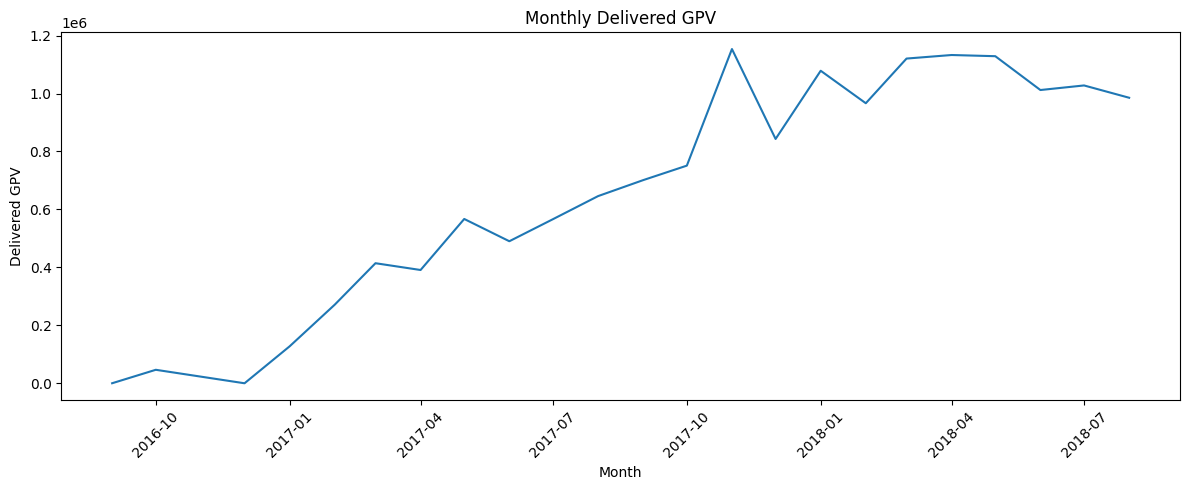

In [44]:
# Plot monthly delivered GPV
plt.figure(figsize=(12, 5))
plt.plot(monthly["purchase_month_start"], monthly["delivered_gpv"])
plt.title("Monthly Delivered GPV")
plt.xlabel("Month")
plt.ylabel("Delivered GPV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / "monthly_delivered_gpv.png", dpi=300, bbox_inches="tight")
plt.show()

#### Plot delivered orders:

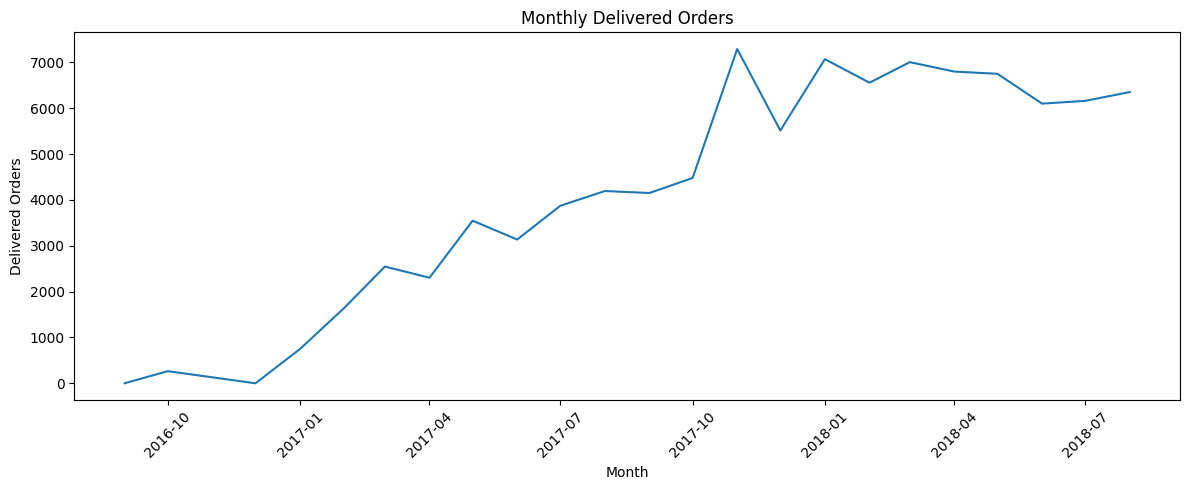

In [45]:
# Plot monthly delivered orders
plt.figure(figsize=(12, 5))
plt.plot(monthly["purchase_month_start"], monthly["delivered_orders"])
plt.title("Monthly Delivered Orders")
plt.xlabel("Month")
plt.ylabel("Delivered Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / "monthly_delivered_orders.png", dpi=300, bbox_inches="tight")
plt.show()

## **Section 6:** Customer retention analysis

### 6.1 Repeat-customer profile

In [17]:
customers["repeat_customer_flag"] = customers["repeat_customer_flag"].astype(int)

repeat_summary = pd.DataFrame({
    "metric": [
        "Total customers",
        "Repeat customers",
        "Repeat customer rate (%)",
        "Average orders per customer",
        "Average CLV"
    ],
    "value": [
        customers.shape[0],
        customers["repeat_customer_flag"].sum(),
        round(customers["repeat_customer_flag"].mean() * 100, 2),
        round(customers["total_orders"].mean(), 2),
        round(customers["lifetime_value_delivered"].mean(), 2)
    ]
})

repeat_summary

,metric,value
0,Total customers,96096.00
1,Repeat customers,2997.00
2,Repeat customer rate (%),3.12
3,Average orders per customer,1.03
4,Average CLV,160.49


### 6.2 Orders per customer distribution

In [18]:
order_dist = customers["total_orders"].value_counts().sort_index()
order_dist.head(10)

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

### 6.3 Compare repeat vs one-time customers

In [22]:
customer_type_summary = (
    customers.assign(customer_type=np.where(customers["repeat_customer_flag"] == 1, "Repeat", "One-Time"))
    .groupby("customer_type", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "count"),
        avg_total_orders=("total_orders", "mean"),
        avg_lifetime_value=("lifetime_value_delivered", "mean"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("avg_delivery_days", "mean")
    )
)

customer_type_summary

,customer_type,customer_count,avg_total_orders,avg_lifetime_value,avg_review_score,avg_delivery_days
0,One-Time,93099,1.000000,155.983178,4.153277,12.574880
1,Repeat,2997,2.116116,300.542993,4.164700,12.344646


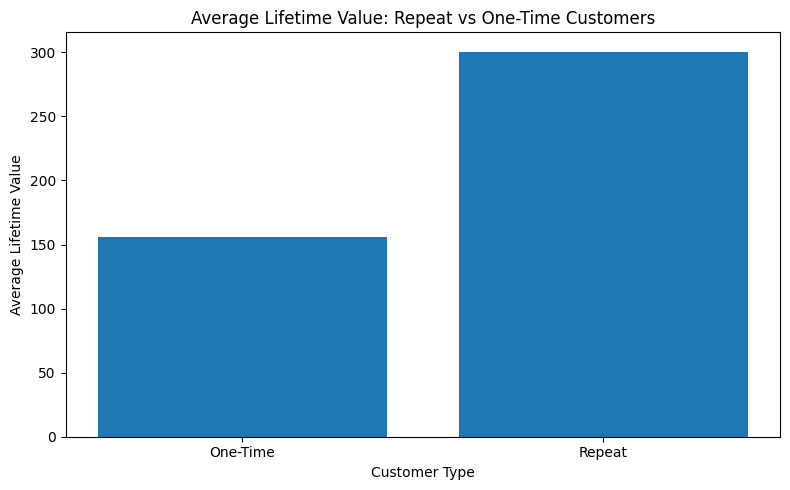

In [46]:
#Plot CLV distribution
plt.figure(figsize=(8, 5))
plt.bar(customer_type_summary["customer_type"], customer_type_summary["avg_lifetime_value"])
plt.title("Average Lifetime Value: Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Average Lifetime Value")
plt.tight_layout()
plt.savefig(output_dir / "repeat_customer_clv.png", dpi=300, bbox_inches="tight")
plt.show()

## **Section 7:** Delivery vs review analysis

### 7.1 Late vs on-time comparison

In [24]:
delivery_review = (
    delivered.assign(
        delivery_bucket=np.where(delivered["late_delivery_flag"] == 1, "Late", "On Time / Early")
    )
    .groupby("delivery_bucket", as_index=False)
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_order_value=("order_value_proxy", "mean")
    )
)

delivery_review

,delivery_bucket,orders,avg_review_score,avg_delivery_days,avg_order_value
0,Late,7826,2.566506,31.518895,172.730673
1,On Time / Early,88652,4.294311,10.884249,158.719656


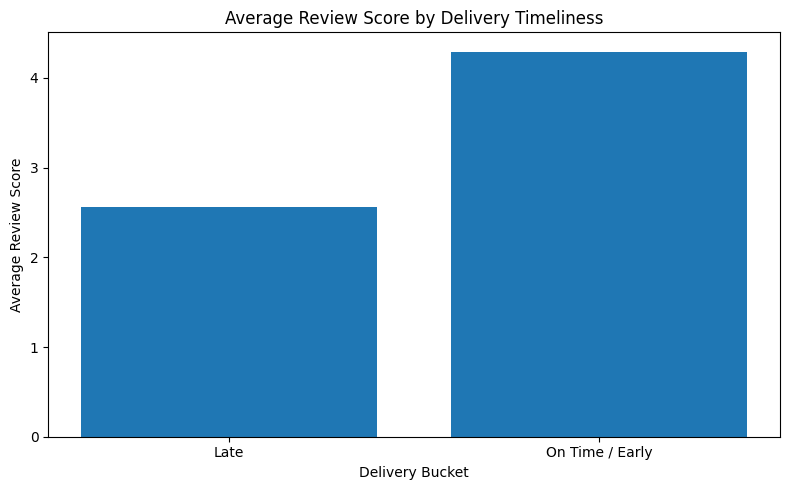

In [47]:
# Check the distribution of review scores
plt.figure(figsize=(8, 5))
plt.bar(delivery_review["delivery_bucket"], delivery_review["avg_review_score"])
plt.title("Average Review Score by Delivery Timeliness")
plt.xlabel("Delivery Bucket")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.savefig(output_dir / "delivery_vs_review_score.png", dpi=300, bbox_inches="tight")
plt.show()

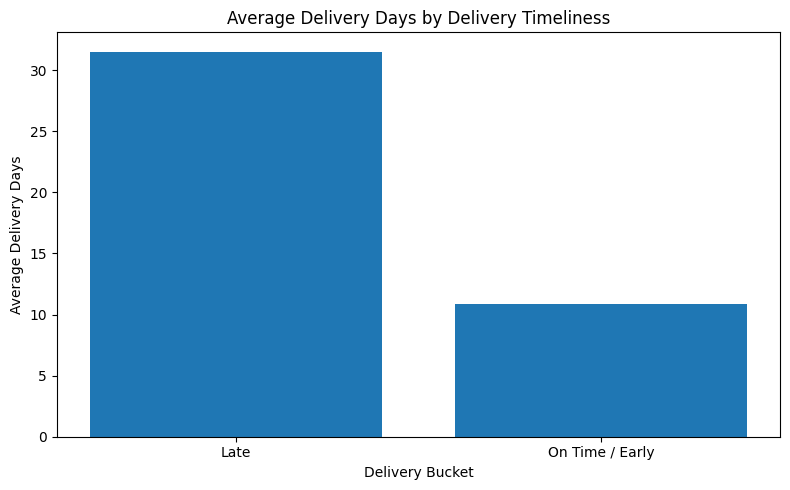

In [48]:
# Check the distribution of delivery days
plt.figure(figsize=(8, 5))
plt.bar(delivery_review["delivery_bucket"], delivery_review["avg_delivery_days"])
plt.title("Average Delivery Days by Delivery Timeliness")
plt.xlabel("Delivery Bucket")
plt.ylabel("Average Delivery Days")
plt.tight_layout()
plt.savefig(output_dir / "delivery_vs_delivery_days.png", dpi=300, bbox_inches="tight")
plt.show()

### 7.2 Relationship between delivery days and review

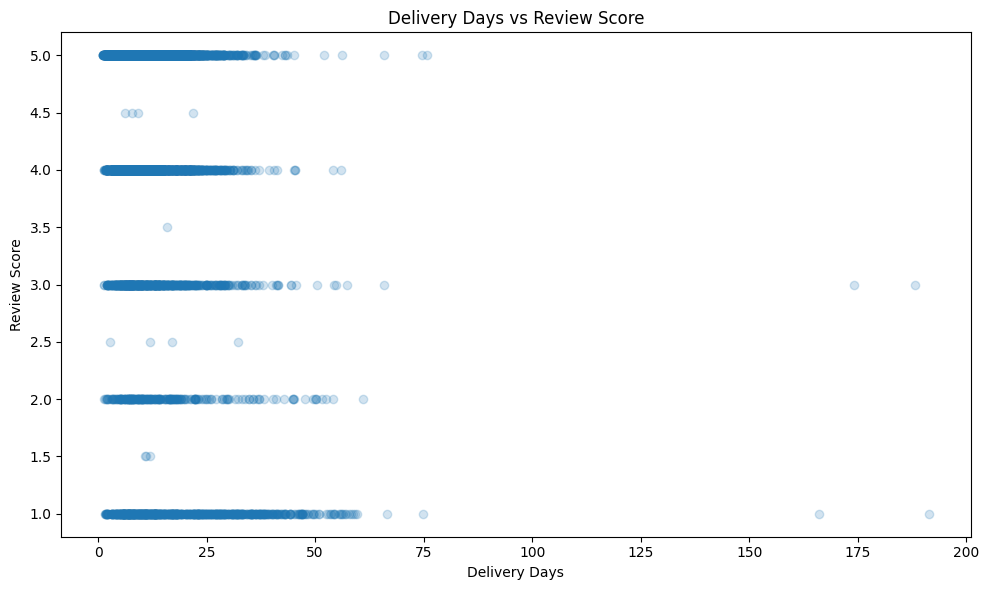

In [ ]:
# Scatter plot of delivery days vs review score
sample_df = delivered.dropna(subset=["delivery_days", "avg_review_score"]).sample(
    n=min(8000, delivered.dropna(subset=["delivery_days", "avg_review_score"]).shape[0]),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df["delivery_days"], sample_df["avg_review_score"], alpha=0.2)
plt.title("Delivery Days vs Review Score")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.tight_layout()
plt.savefig(output_dir / "delivery_days_vs_review_score.png", dpi=300, bbox_inches="tight")
plt.show()

 ### 7.3 Late delivery rate by review bucket

In [28]:
late_by_review_bucket = (
    delivered.groupby("review_bucket", as_index=False)
    .agg(
        orders=("order_id", "count"),
        late_delivery_rate=("late_delivery_flag", "mean")
    )
)

late_by_review_bucket["late_delivery_rate_pct"] = late_by_review_bucket["late_delivery_rate"] * 100
late_by_review_bucket

,review_bucket,orders,late_delivery_rate,late_delivery_rate_pct
0,Very Low (<=2),12237,0.337991,33.799134
1,Low (2-3],7945,0.110006,11.000629
2,Medium (3-4],18892,0.050180,5.017997
3,High (4-5],56758,0.030005,3.000458


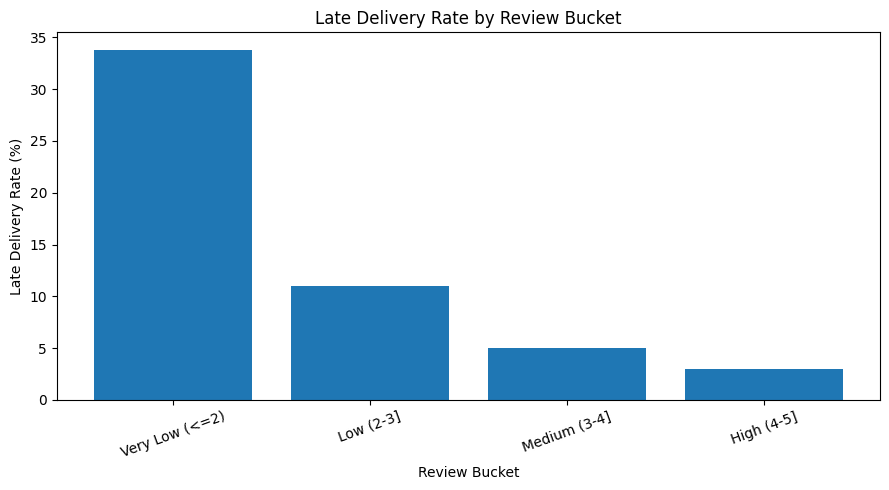

In [50]:
# Check the distribution of review scores
plt.figure(figsize=(9, 5))
plt.bar(late_by_review_bucket["review_bucket"].astype(str), late_by_review_bucket["late_delivery_rate_pct"])
plt.title("Late Delivery Rate by Review Bucket")
plt.xlabel("Review Bucket")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(output_dir / "late_delivery_by_review_bucket.png", dpi=300, bbox_inches="tight")
plt.show()

 #### Delivery timeliness is a major driver of customer satisfaction. Late deliveries are associated with much lower review scores, which supports prioritizing logistics reliability, seller SLA tracking, and region/category-level fulfillment fixes.

## **Section 8:** Category analysis

### 8.1 Top 10 categories by product revenue

In [31]:
category_totals = (
    category_perf.groupby("product_category_en", as_index=False)
    .agg(
        delivered_orders=("delivered_orders", "sum"),
        product_revenue=("product_revenue", "sum"),
        freight_revenue=("freight_revenue", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        late_delivery_rate=("late_delivery_rate", "mean")
    )
)

top10_categories = category_totals.sort_values("product_revenue", ascending=False).head(10)
top10_categories

,product_category_en,delivered_orders,product_revenue,freight_revenue,avg_review_score,late_delivery_rate
44,health_beauty,8647,1233131.72,178957.81,4.061818,0.115732
73,watches_gifts,5495,1166176.98,98156.14,4.185714,0.069071
8,bed_bath_table,9272,1023434.76,201774.50,4.040476,0.070300
68,sports_leisure,7530,954852.55,163404.36,4.262857,0.062329
16,computers_accessories,6530,888724.61,143999.16,4.108571,0.063462
40,furniture_decor,6307,711927.69,168402.23,4.064762,0.073862
50,housewares,5743,615628.69,142763.56,4.146190,0.061290
21,cool_stuff,3559,610204.10,81476.79,4.213333,0.061452
6,auto,3810,578966.65,90488.10,4.118571,0.072638
72,toys,3804,471286.48,75774.58,4.264286,0.062019


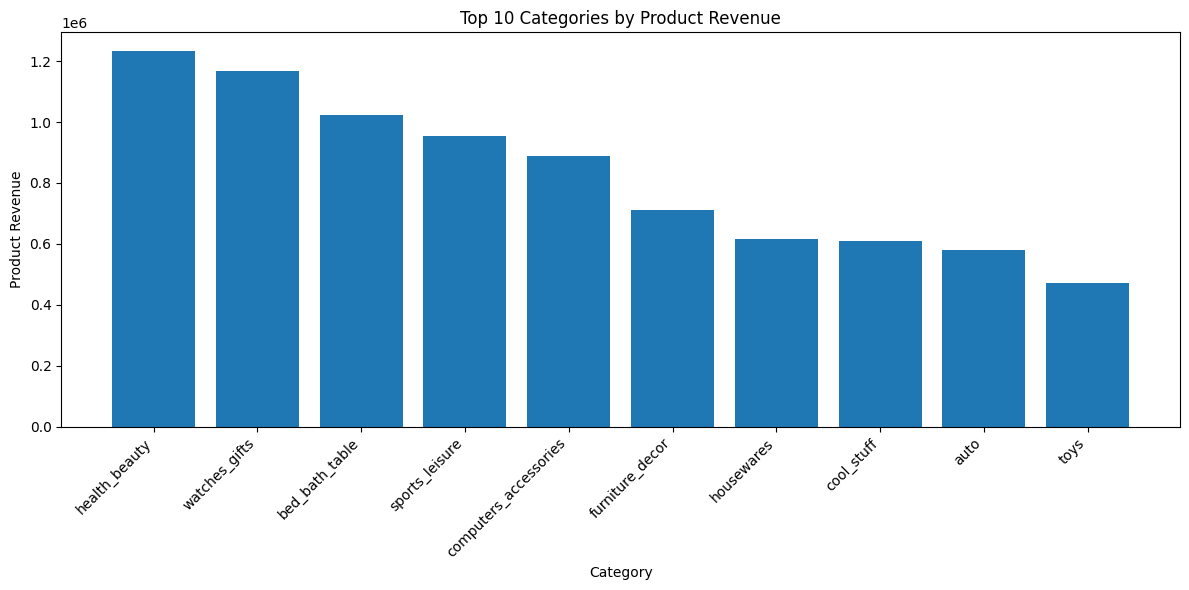

In [51]:
# Plot top 10 categories by product revenue
plt.figure(figsize=(12, 6))
plt.bar(top10_categories["product_category_en"], top10_categories["product_revenue"])
plt.title("Top 10 Categories by Product Revenue")
plt.xlabel("Category")
plt.ylabel("Product Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "top10_categories_by_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.2 Low-review categories with meaningful volume

In [33]:
bottom_review_categories = (
    category_totals[category_totals["delivered_orders"] >= 100]
    .sort_values("avg_review_score", ascending=True)
    .head(10)
)

bottom_review_categories

,product_category_en,delivered_orders,product_revenue,freight_revenue,avg_review_score,late_delivery_rate
58,office_furniture,1254,268154.31,67057.05,3.552857,0.090067
20,construction_tools_safety,159,38773.22,3730.80,3.859286,0.030243
31,fashion_male_clothing,106,10452.33,2062.62,3.871053,0.074165
48,home_confort,392,58008.45,8429.77,3.898421,0.092342
5,audio,348,50570.60,5684.72,3.906500,0.113115
19,construction_tools_lights,242,39957.00,7490.14,3.910000,0.138857
35,fixed_telephony,212,55315.21,4501.33,3.919524,0.058562
65,signaling_and_security,138,21315.05,6477.54,3.920556,0.058139
34,fashion_underwear_beach,117,9305.95,1854.07,3.922000,0.122420
1,agro_industry_and_commerce,177,70566.10,5637.20,3.940526,0.033537


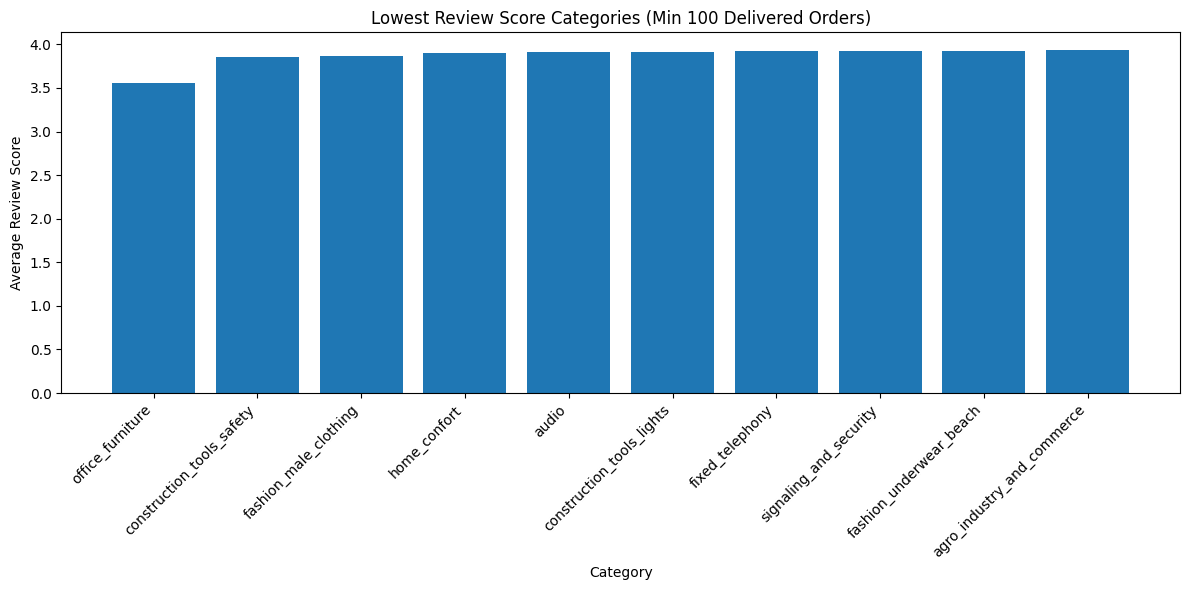

In [52]:
# Plot bottom 10 categories by average review score (with min 100 delivered orders)
plt.figure(figsize=(12, 6))
plt.bar(bottom_review_categories["product_category_en"], bottom_review_categories["avg_review_score"])
plt.title("Lowest Review Score Categories (Min 100 Delivered Orders)")
plt.xlabel("Category")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "bottom10_categories_by_review_score.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.3 Revenue vs review score bubble-style analysis

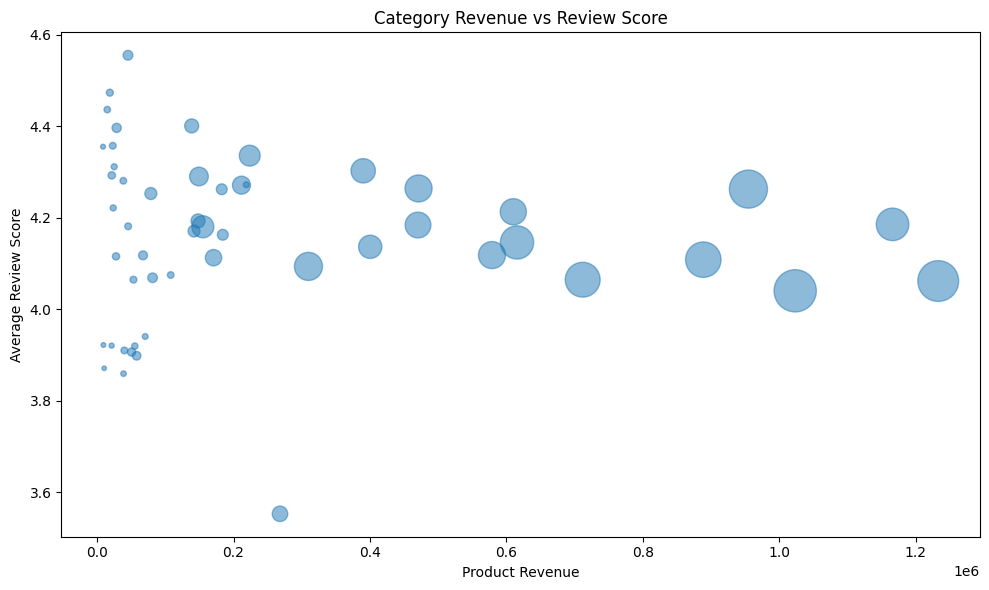

In [53]:
# Scatter plot of category revenue vs review score (size by delivered orders)
cat_plot_df = category_totals[category_totals["delivered_orders"] >= 100].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    cat_plot_df["product_revenue"],
    cat_plot_df["avg_review_score"],
    s=cat_plot_df["delivered_orders"] / 10,
    alpha=0.5
)
plt.title("Category Revenue vs Review Score")
plt.xlabel("Product Revenue")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.savefig(output_dir / "category_revenue_vs_review_score.png", dpi=300, bbox_inches="tight")
plt.show()

#### Not all high-revenue categories deliver equally strong customer experience. office_furniture is especially important because it combines meaningful revenue with weak reviews, making it a likely candidate for quality, packaging, or fulfillment intervention.

## **Section 9:** Geographical analysis

### 9.1 Top states by delivered GPV

In [36]:
state_totals = (
    state_perf.groupby("customer_state", as_index=False)
    .agg(
        delivered_orders=("delivered_orders", "sum"),
        delivered_gpv=("delivered_gpv", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("avg_delivery_days", "mean"),
        late_delivery_rate=("late_delivery_rate", "mean")
    )
)

top_states = state_totals.sort_values("delivered_gpv", ascending=False).head(10)
top_states

,customer_state,delivered_orders,delivered_gpv,avg_review_score,avg_delivery_days,late_delivery_rate
25,SP,40501,5770409.65,4.085455,11.507273,0.094405
18,RJ,12350,2055690.45,4.022381,14.687143,0.104262
10,MG,11354,1819277.61,4.197143,12.097143,0.041433
22,RS,5345,861802.40,4.209048,14.982857,0.056319
17,PR,4923,781919.55,4.275000,11.856364,0.039368
23,SC,3546,595208.40,4.139048,14.988571,0.084714
4,BA,3256,591270.60,3.960952,19.356667,0.119290
6,DF,2080,346146.17,4.085238,13.700952,0.057629
8,GO,1957,334294.22,4.151429,15.552857,0.063771
7,ES,1995,317682.65,4.095238,15.914286,0.097505


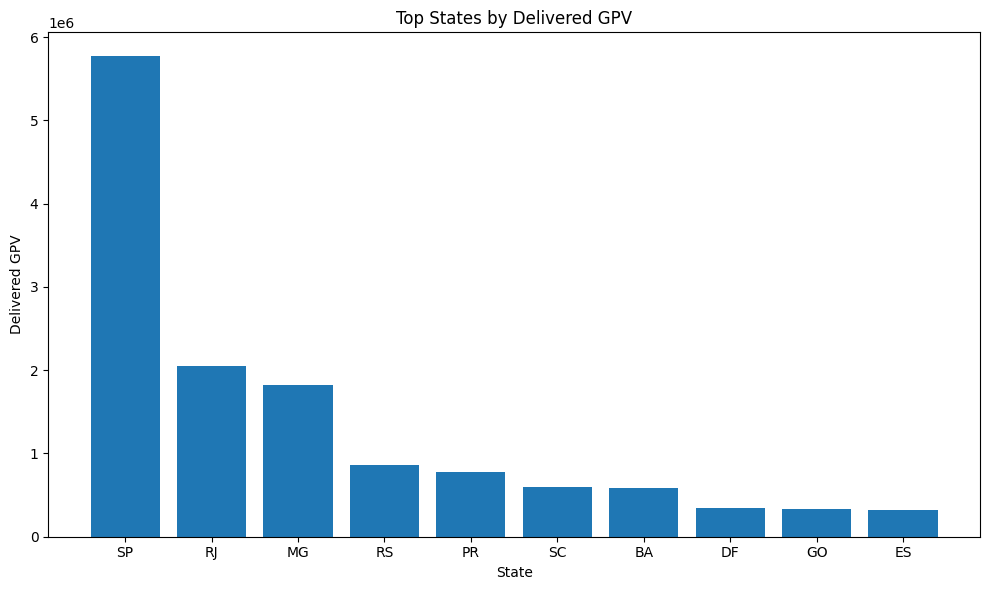

In [54]:
# Plot top states by delivered GPV
plt.figure(figsize=(10, 6))
plt.bar(top_states["customer_state"], top_states["delivered_gpv"])
plt.title("Top States by Delivered GPV")
plt.xlabel("State")
plt.ylabel("Delivered GPV")
plt.tight_layout()
plt.savefig(output_dir / "top_states_by_gpv.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.2 State delivery quality comparison

In [39]:
# Compare delivery quality within the top revenue states
state_quality = state_totals[
    state_totals["customer_state"].isin(top_states["customer_state"])
].copy()

state_quality = state_quality.sort_values("avg_delivery_days", ascending=False)
state_quality

,customer_state,delivered_orders,delivered_gpv,avg_review_score,avg_delivery_days,late_delivery_rate
4,BA,3256,591270.60,3.960952,19.356667,0.119290
7,ES,1995,317682.65,4.095238,15.914286,0.097505
8,GO,1957,334294.22,4.151429,15.552857,0.063771
23,SC,3546,595208.40,4.139048,14.988571,0.084714
22,RS,5345,861802.40,4.209048,14.982857,0.056319
18,RJ,12350,2055690.45,4.022381,14.687143,0.104262
6,DF,2080,346146.17,4.085238,13.700952,0.057629
10,MG,11354,1819277.61,4.197143,12.097143,0.041433
17,PR,4923,781919.55,4.275000,11.856364,0.039368
25,SP,40501,5770409.65,4.085455,11.507273,0.094405


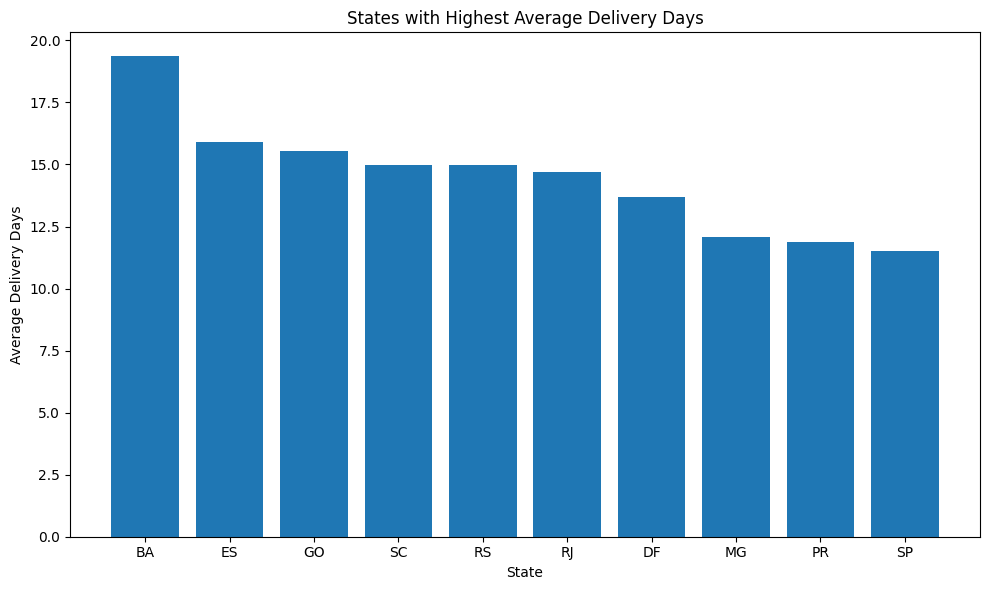

In [55]:
# Plot states by average delivery days
plt.figure(figsize=(10, 6))
plt.bar(state_quality["customer_state"], state_quality["avg_delivery_days"])
plt.title("States with Highest Average Delivery Days")
plt.xlabel("State")
plt.ylabel("Average Delivery Days")
plt.tight_layout()
plt.savefig(output_dir / "top_states_by_delivery_days.png", dpi=300, bbox_inches="tight")
plt.show()

#### Geography shows that scale and service quality are not evenly distributed. São Paulo dominates marketplace value, while states like Bahia show weaker review performance and slower fulfillment, pointing to region-specific operational bottlenecks.

## **Section 10:** Python Analysis Summary

The Python analysis reinforces three main business themes:

1. Olist’s marketplace expanded over time, but final delivered-order trend visuals should exclude September–October 2018 because the tail appears incomplete.
2. Customer retention is weak, with repeat customers representing a very small share of the customer base, suggesting a major opportunity in loyalty and post-purchase engagement.
3. Delivery reliability strongly affects satisfaction. Late deliveries are associated with sharply lower review scores, making logistics performance one of the most important drivers of customer experience.
4. Revenue concentration is high in a few categories and states, but customer experience is uneven. Categories such as office_furniture and states such as BA warrant closer operational review.